In [7]:
import sys
sys.path.append("../src")

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import transforms, models
from torch.utils.data import DataLoader, random_split

from config import TRAIN_DIR, TEST_DIR, CLASSES, IMAGE_SIZE, SEED
from dataset import BrainTumorDataset

In [8]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

device

device(type='mps')

In [9]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [10]:
full_train_dataset = BrainTumorDataset(
    TRAIN_DIR,
    CLASSES,
    transform=transform
)

test_dataset = BrainTumorDataset(
    TEST_DIR,
    CLASSES,
    transform=transform
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [11]:
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/krishivshah/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


In [12]:
for param in model.parameters():
    param.requires_grad = False

In [15]:
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, len(CLASSES))
)

model = model.to(device)

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [17]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [18]:
def run_epoch(model, data_loader, criterion, optimizer=None, training=False):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad()
        
        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()
        
        total_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    average_loss = total_loss / total
    accuracy = correct / total

    return average_loss, accuracy

In [19]:
EPOCHS = 5

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        training=True
    )

    val_loss, val_acc = run_epoch(
        model,
        val_loader,
        criterion,
        training=False
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 1/5 | Train Loss: 0.6370 | Train Acc: 0.7562 | Val Loss: 0.3659 | Val Acc: 0.8625
Epoch 2/5 | Train Loss: 0.4056 | Train Acc: 0.8458 | Val Loss: 0.3391 | Val Acc: 0.8670
Epoch 3/5 | Train Loss: 0.3623 | Train Acc: 0.8679 | Val Loss: 0.2869 | Val Acc: 0.8938
Epoch 4/5 | Train Loss: 0.3193 | Train Acc: 0.8824 | Val Loss: 0.2790 | Val Acc: 0.8902
Epoch 5/5 | Train Loss: 0.2978 | Train Acc: 0.8884 | Val Loss: 0.2591 | Val Acc: 0.8946


In [20]:
for epoch in range(6, 11):
    train_loss, train_acc = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        training=True
    )

    val_loss, val_acc = run_epoch(
        model,
        val_loader,
        criterion,
        training=False
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/10 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 6/10 | Train Loss: 0.2821 | Train Acc: 0.8938 | Val Loss: 0.2815 | Val Acc: 0.8804
Epoch 7/10 | Train Loss: 0.2635 | Train Acc: 0.9000 | Val Loss: 0.3196 | Val Acc: 0.8679
Epoch 8/10 | Train Loss: 0.2599 | Train Acc: 0.8989 | Val Loss: 0.2717 | Val Acc: 0.8955
Epoch 9/10 | Train Loss: 0.2493 | Train Acc: 0.9060 | Val Loss: 0.2256 | Val Acc: 0.9223
Epoch 10/10 | Train Loss: 0.2343 | Train Acc: 0.9136 | Val Loss: 0.2536 | Val Acc: 0.8955


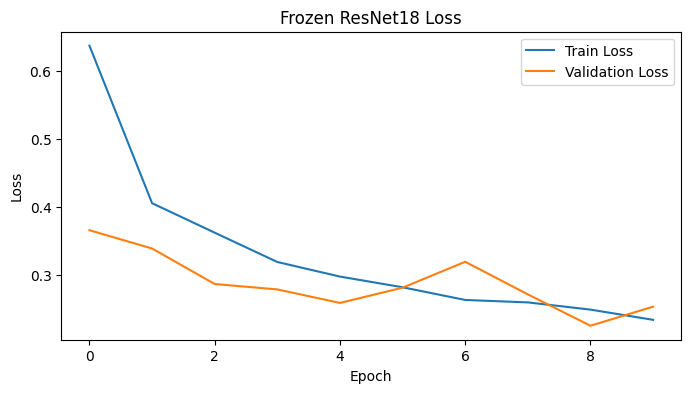

In [23]:
plt.figure(figsize=(8, 4))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("Frozen ResNet18 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

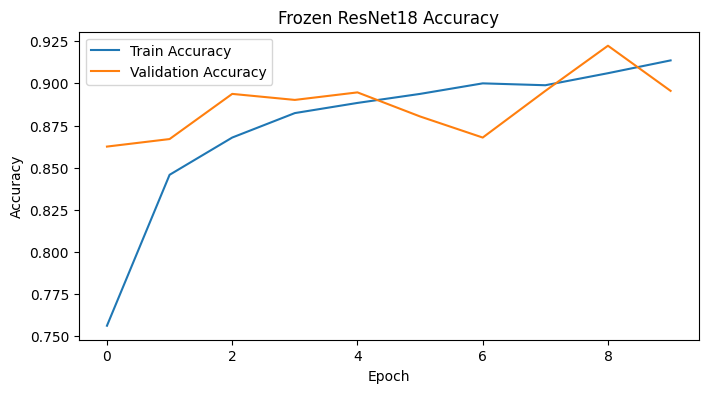

In [24]:
plt.figure(figsize=(8, 4))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.title("Frozen ResNet18 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [21]:
best_val_acc = max(history["val_acc"])
best_epoch = history["val_acc"].index(best_val_acc) + 1

best_epoch, best_val_acc

(9, 0.9223214285714286)

In [22]:
torch.save(model.state_dict(), "../models/resnet18_frozen.pth")

In [25]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [26]:
test_accuracy = (
    sum(p == y for p, y in zip(all_predictions, all_labels))
    / len(all_labels)
)

test_accuracy

np.float64(0.860625)

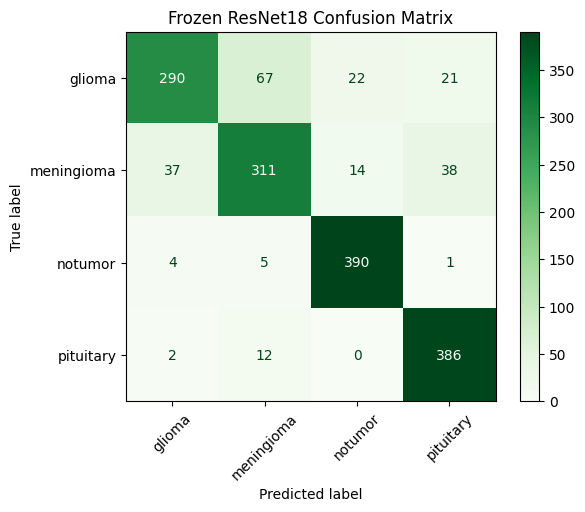

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)

disp.plot(cmap="Greens", xticks_rotation=45)
plt.title("Frozen ResNet18 Confusion Matrix")
plt.show()

In [28]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASSES
    )
)

              precision    recall  f1-score   support

      glioma       0.87      0.72      0.79       400
  meningioma       0.79      0.78      0.78       400
     notumor       0.92      0.97      0.94       400
   pituitary       0.87      0.96      0.91       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600



In [29]:
for param in model.layer4.parameters():
    param.requires_grad = True

In [30]:
optimizer = optim.Adam(
    [
        {"params": model.layer4.parameters(), "lr": 1e-5},
        {"params": model.fc.parameters(), "lr": 1e-4}
    ]
)

In [31]:
for epoch in range(11, 16):
    train_loss, train_acc = run_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        training=True
    )

    val_loss, val_acc = run_epoch(
        model,
        val_loader,
        criterion,
        training=False
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/15 | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch 11/15 | Train Loss: 0.1785 | Train Acc: 0.9324 | Val Loss: 0.1717 | Val Acc: 0.9437
Epoch 12/15 | Train Loss: 0.1026 | Train Acc: 0.9665 | Val Loss: 0.1566 | Val Acc: 0.9411
Epoch 13/15 | Train Loss: 0.0656 | Train Acc: 0.9806 | Val Loss: 0.1420 | Val Acc: 0.9500
Epoch 14/15 | Train Loss: 0.0477 | Train Acc: 0.9862 | Val Loss: 0.1342 | Val Acc: 0.9545
Epoch 15/15 | Train Loss: 0.0368 | Train Acc: 0.9891 | Val Loss: 0.1354 | Val Acc: 0.9482


In [32]:
best_val_acc = max(history["val_acc"])
best_epoch = history["val_acc"].index(best_val_acc) + 1

best_epoch, best_val_acc

(14, 0.9544642857142858)

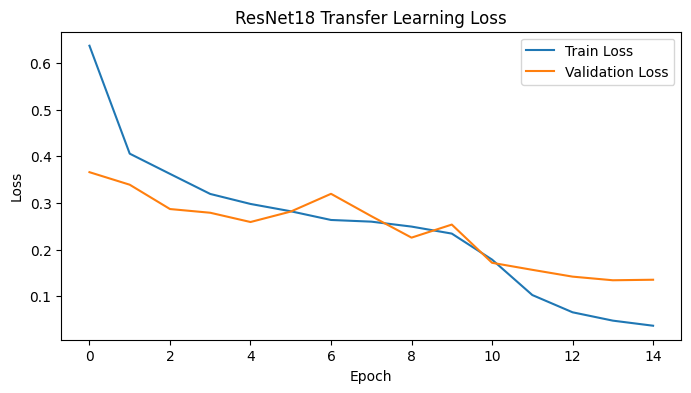

In [44]:
plt.figure(figsize=(8, 4))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("ResNet18 Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig(
    "../figures/resnet18_loss_curve.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

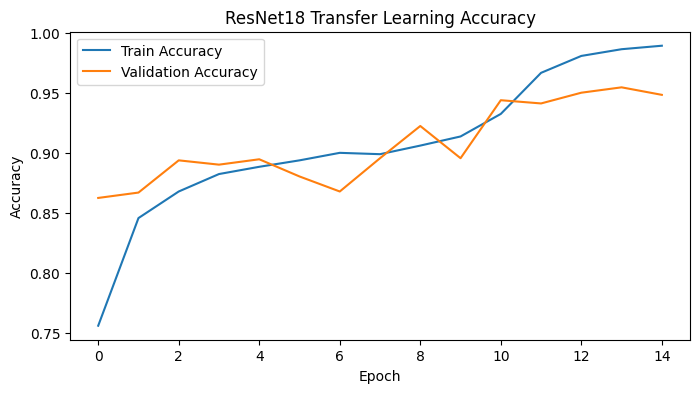

In [43]:
plt.figure(figsize=(8, 4))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.title("ResNet18 Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig(
    "../figures/resnet18_accuracy_curve.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [35]:
torch.save(model.state_dict(), "../models/resnet18_finetuned.pth")

In [36]:
all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [37]:
test_accuracy = (
    sum(p == y for p, y in zip(all_predictions, all_labels))
    / len(all_labels)
)

test_accuracy

np.float64(0.91)

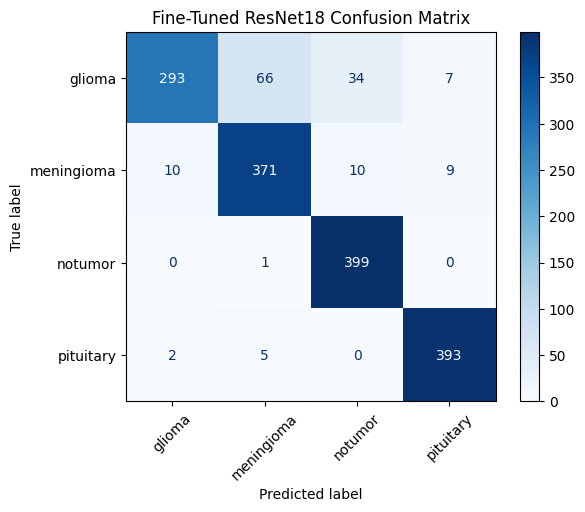

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASSES
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Fine-Tuned ResNet18 Confusion Matrix")

plt.savefig(
    "../figures/finetuned_resnet_confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [41]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=CLASSES
    )
)

              precision    recall  f1-score   support

      glioma       0.96      0.73      0.83       400
  meningioma       0.84      0.93      0.88       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.96      0.98      0.97       400

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



In [46]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": CLASSES,
        "image_size": 224,
        "model_name": "resnet18_finetuned",
        "validation_accuracy": 0.955,
        "test_accuracy": 0.91,
        "notes": "Fine-tuned ResNet18 with layer4 and classifier head trainable."
    },
    "../models/resnet18_brain_mri_v1.pth"
)